# Task 4: Predicting Insurance Claim Amounts

________

## Problem Statement

The objective is to estimate medical insurance charges based on personal data such as age, BMI,
smoking status, and region. This is a regression problem — unlike classification (predicting a category),
regression predicts a continuous number. We use the Medical Cost Personal Dataset available on
Kaggle.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
print("Libraries imported successfully!")

Libraries imported successfully!


### Load the Dataset

In [2]:
df = pd.read_csv('insurance.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1338, 7)

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Dataset Understanding

In [3]:
print("Columns:", list(df.columns))
print("\nData types:")
print(df.dtypes)

print("\nStatistical Summary:")
df.describe()

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check unique values in categorical columns
print("\nSmoker values:", df['smoker'].unique())
print("Sex values: ", df['sex'].unique())
print("Region values:", df['region'].unique())

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Statistical Summary:
Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Smoker values: ['yes' 'no']
Sex values:  ['female' 'male']
Region values: ['southwest' 'southeast' 'northwest' 'northeast']


### Data Cleaning and Preparation

In [4]:
le = LabelEncoder()

# Encode binary columns
df['sex'] = le.fit_transform(df['sex']) # female=0, male=1
df['smoker'] = le.fit_transform(df['smoker']) # no=0, yes=1

# One-Hot Encode region (4 categories)
df = pd.get_dummies(df, columns=['region'], drop_first=True)
print("Columns after encoding:")
print(list(df.columns))
df.head()

Columns after encoding:
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


### Exploratory Data Analysis (EDA)

- Charges Distribution

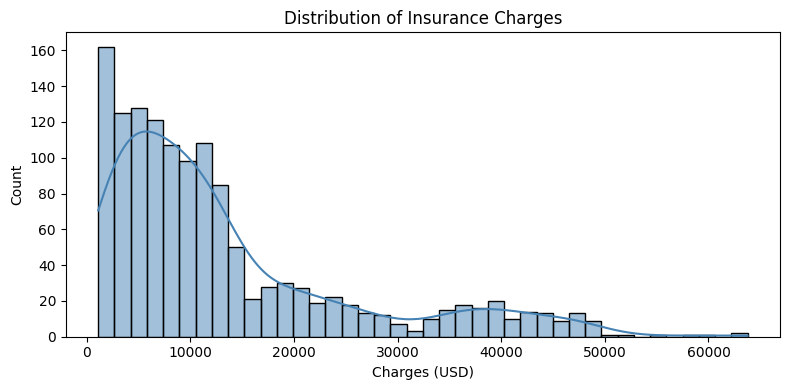

Insight: Charges are right-skewed — most are low but some are very high.


In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(df['charges'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges (USD)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('charges_dist.png', dpi=150)
plt.show()
print("Insight: Charges are right-skewed — most are low but some are very high.")

- Smoker vs Non-Smoker Charges

C:\Users\admin\AppData\Local\Temp\ipykernel_22548\3720661830.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='smoker', y='charges', palette='Set1')


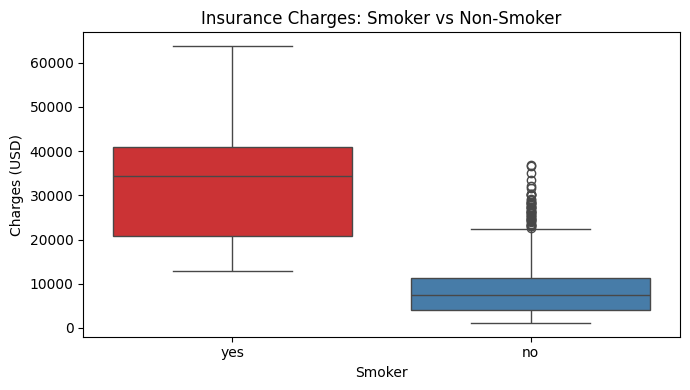

Insight: Smokers pay dramatically more — smoking is the biggest cost driver.


In [6]:
# Reload original for EDA visualizations
df_eda = pd.read_csv('insurance.csv')

plt.figure(figsize=(7, 4))
sns.boxplot(data=df_eda, x='smoker', y='charges', palette='Set1')
plt.title('Insurance Charges: Smoker vs Non-Smoker')
plt.xlabel('Smoker')
plt.ylabel('Charges (USD)')
plt.tight_layout()
plt.savefig('smoker_charges.png', dpi=150)
plt.show()

print("Insight: Smokers pay dramatically more — smoking is the biggest cost driver.")

- BMI vs Charges

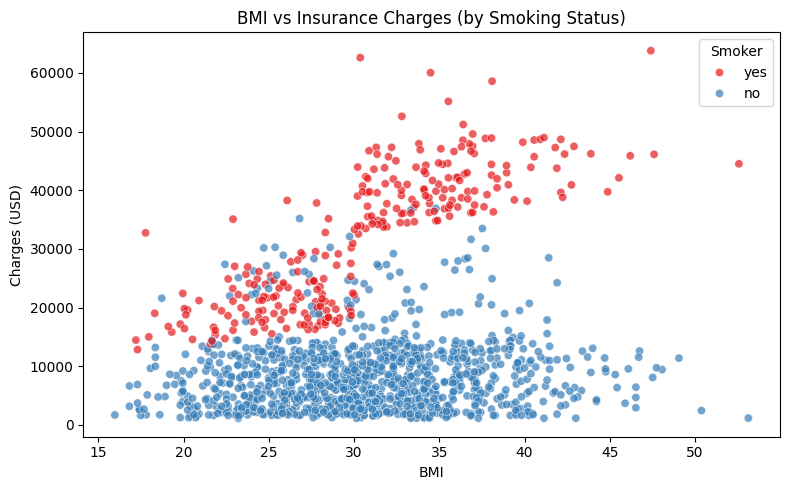

Insight: High BMI + smoker = highest charges by far.


In [7]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df_eda, x='bmi', y='charges',
hue='smoker', palette='Set1', alpha=0.7)
plt.title('BMI vs Insurance Charges (by Smoking Status)')
plt.xlabel('BMI')
plt.ylabel('Charges (USD)')
plt.legend(title='Smoker')
plt.tight_layout()
plt.savefig('bmi_charges.png', dpi=150)
plt.show()

print("Insight: High BMI + smoker = highest charges by far.")

- Age vs Charges

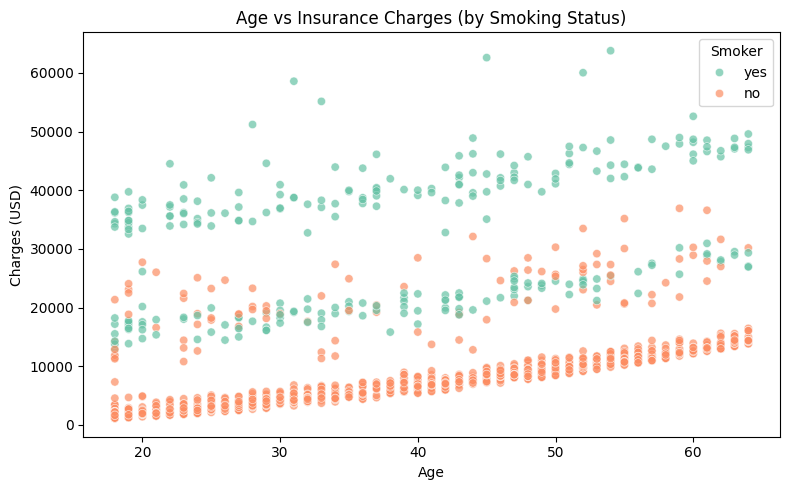

Insight: Charges increase with age; smokers form a clearly higher band.


In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_eda, x='age', y='charges',
                hue='smoker', palette='Set2', alpha=0.7)

plt.title('Age vs Insurance Charges (by Smoking Status)')
plt.xlabel('Age')
plt.ylabel('Charges (USD)')
plt.legend(title='Smoker')
plt.tight_layout()
plt.savefig('age_charges.png', dpi=150)
plt.show()

print("Insight: Charges increase with age; smokers form a clearly higher band.")

- Correlation Heatmap

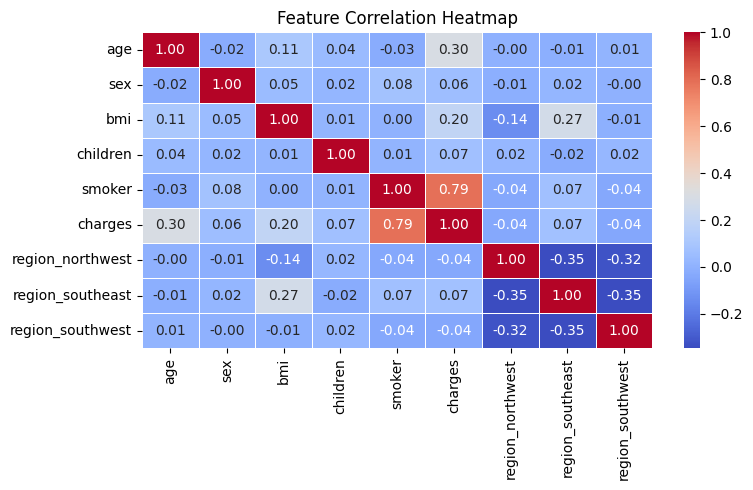

Insight: smoker has the highest correlation with charges (~0.79).


In [9]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)

plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

print("Insight: smoker has the highest correlation with charges (~0.79).")

### Prepare Features and Split Data

In [10]:
X = df.drop('charges', axis=1)
y = df['charges']

print("Feature columns:", list(X.columns))

print("Target: charges")

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Feature columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']
Target: charges

Training samples: 1070
Testing samples: 268


### Train Regression Models

- Linear Regression

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print("=== Linear Regression ===")
print(f"MAE: {lr_mae:,.2f}")
print(f"RMSE: {lr_rmse:,.2f}")
print(f"R2: {lr_r2:.4f}")

=== Linear Regression ===
MAE: 4,181.19
RMSE: 5,796.28
R2: 0.7836


- Random Forest Regressor

In [14]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("=== Random Forest Regressor ===")
print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R2: {rf_r2:.4f}")

=== Random Forest Regressor ===
MAE: 2550.67
RMSE: 4577.74
R2: 0.8650


### Visualize Predictions vs Actual

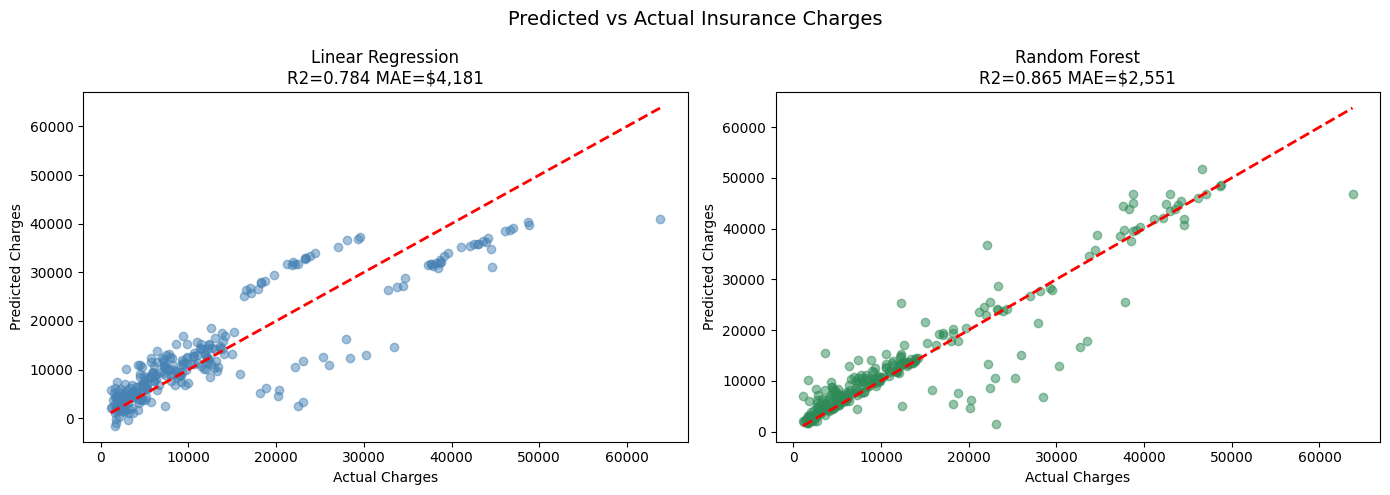

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Linear Regression
axes[0].scatter(y_test, lr_preds, alpha=0.5, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2)

axes[0].set_title(f'Linear Regression\nR2={lr_r2:.3f} MAE=${lr_mae:,.0f}')
axes[0].set_xlabel('Actual Charges')
axes[0].set_ylabel('Predicted Charges')

# Random Forest
axes[1].scatter(y_test, rf_preds, alpha=0.5, color='seagreen')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2)

axes[1].set_title(f'Random Forest\nR2={rf_r2:.3f} MAE=${rf_mae:,.0f}')
axes[1].set_xlabel('Actual Charges')
axes[1].set_ylabel('Predicted Charges')

plt.suptitle('Predicted vs Actual Insurance Charges', fontsize=14)
plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=150)
plt.show()

# The red dashed line = perfect predictions. Closer = better model.

### Feature Importance

C:\Users\admin\AppData\Local\Temp\ipykernel_22548\3370167722.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='magma')


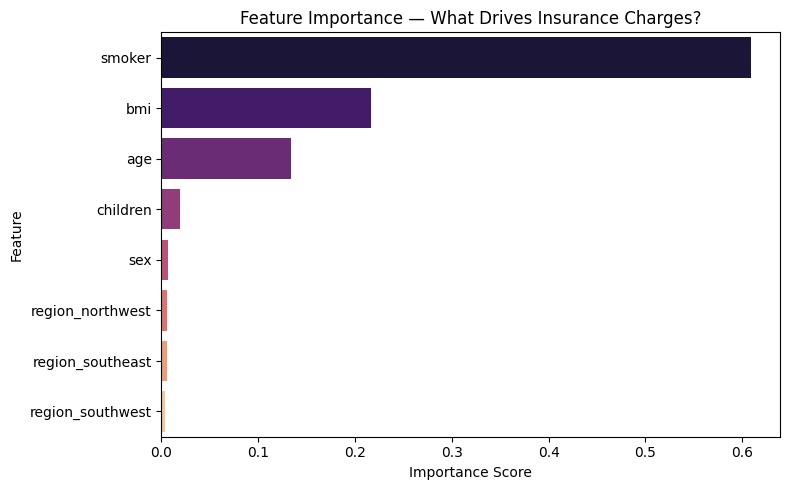

         Feature  Importance
          smoker    0.608618
             bmi    0.216500
             age    0.134203
        children    0.019463
             sex    0.006373
region_northwest    0.005621
region_southeast    0.005284
region_southwest    0.003938


In [16]:
importances = rf.feature_importances_
feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='magma')
plt.title('Feature Importance — What Drives Insurance Charges?')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('insurance_feature_importance.png', dpi=150)
plt.show()

print(feat_df.to_string(index=False))

### Conclusion — Key Insights

• **Smoking status** is by far the strongest predictor of high insurance charges.

• **BMI + smoking** combined leads to the highest charges in the dataset.

• **Age** is the second most important feature — older = higher charges.

• **Linear Regression** achieves R2 ~0.75, meaning it explains 75% of variance.

• **Random Forest** improves this to ~0.87, capturing non-linear patterns better.

• **MAE** tells us the average prediction is off by around $2,500–$4,000.

• **RMSE** is higher than MAE because it penalises large errors more heavily.

__________